# Issue 59: User Activity — Trajectory Analysis

This notebook analyzes user contribution trajectories using three datasets: ratings, note writing, and note requesting. Each dataset is aggregated per user per month (`userMonth` = months since the user's first action on Community Notes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

DATA_DIR = '../../../data - 3.17/Archive'
OUT_DIR  = '.'

rating  = pd.read_parquet(f'{DATA_DIR}/sample_user_rating_traj.parquet')
note    = pd.read_parquet(f'{DATA_DIR}/sample_user_note_traj.parquet')
request = pd.read_parquet(f'{DATA_DIR}/sample_user_request_traj.parquet')

rating  = rating .rename(columns={'raterParticipantId':      'userId'})
note    = note   .rename(columns={'noteAuthorParticipantId': 'userId'})
request = request.rename(columns={'requesterParticipantId':  'userId'})

rating ['type']    = 'rating'
note   ['type']    = 'writing'
request['type']    = 'requesting'

rating ['activity'] = rating ['notesRated']
note   ['activity'] = note   ['notesCreated']
request['activity'] = request['requestsMade']

cols = ['userId', 'userMonth', 'calendarMonth', 'type', 'activity']
df = pd.concat([rating[cols], note[cols], request[cols]], ignore_index=True)
print('combined shape:', df.shape)

combined shape: (98560, 5)


## Q1: What contribution types are most common in users' first active month?

I filtered for `userMonth == 0` and counted how many unique users appear in each type's dataset for that month.

In [2]:
month0 = df[df['userMonth'] == 0]
type_counts = month0.groupby('type')['userId'].nunique()
pct = (type_counts / type_counts.sum() * 100).round(1)
print('unique users by type in userMonth 0:')
print(type_counts)
print('\n% of first-month users:')
print(pct)

unique users by type in userMonth 0:
type
rating         5805
requesting    14282
writing          56
Name: userId, dtype: int64

% of first-month users:
type
rating        28.8
requesting    70.9
writing        0.3
Name: userId, dtype: float64


In users' first active month, **requesting is by far the most common contribution type at 70.9%**, followed by rating at 28.8%. Writing notes is extremely rare at only 0.3%. This makes sense — requesting a note is the lowest-effort action and doesn't require any special knowledge of the platform, while writing notes requires more familiarity with Community Notes guidelines.

## Q2: Dominant contribution type by user month

For each user-month, I identified the user's dominant contribution type (whichever type had the highest activity count). Then I plotted the percentage of users dominated by each type across user months 0–24.

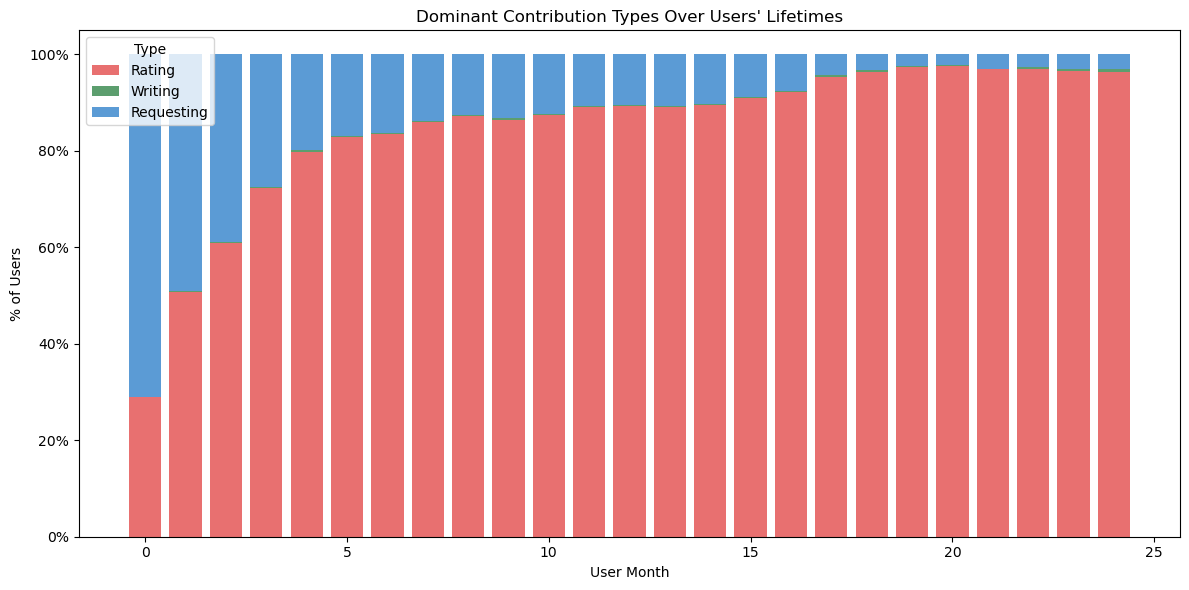

In [3]:
dominant = (
    df.sort_values('activity', ascending=False)
    .groupby(['userId', 'userMonth'])
    .first()
    .reset_index()
    [['userId', 'userMonth', 'type']]
    .rename(columns={'type': 'dominant_type'})
)

dom_counts = (
    dominant.groupby(['userMonth', 'dominant_type'])['userId']
    .nunique()
    .reset_index()
    .rename(columns={'userId': 'n_users'})
)

dom_pivot = dom_counts.pivot(index='userMonth', columns='dominant_type', values='n_users').fillna(0)
dom_pct   = dom_pivot.div(dom_pivot.sum(axis=1), axis=0) * 100
dom_pct_plot = dom_pct[dom_pct.index <= 24]

colors = {'rating': '#E87070', 'writing': '#5C9E6E', 'requesting': '#5B9BD5'}
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(dom_pct_plot))
for col in ['rating', 'writing', 'requesting']:
    if col in dom_pct_plot.columns:
        ax.bar(dom_pct_plot.index, dom_pct_plot[col],
               bottom=bottom, label=col.capitalize(),
               color=colors.get(col, 'gray'))
        bottom += dom_pct_plot[col].values

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('User Month')
ax.set_ylabel('% of Users')
ax.set_title("Dominant Contribution Types Over Users' Lifetimes")
ax.legend(title='Type')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/q2_dominant_type_by_user_month.png', dpi=150)
plt.show()

The pattern here is really striking. In `userMonth 0`, requesting dominates (~70% of users), but this flips almost immediately — by `userMonth 1`, rating becomes the dominant type and stays that way for the rest of users' lifetimes. Writing notes remains a very small fraction throughout.

This suggests that many users start out by requesting notes on content they find misleading, but those who stick around quickly transition into becoming raters. The requesting-heavy cohort likely churns out early, leaving behind a more committed group of raters.

## Q3: Individual user trajectories

I selected 3 users who were active for at least 5 months and had at least 2 different contribution types, to show how individual behavior changes over time.

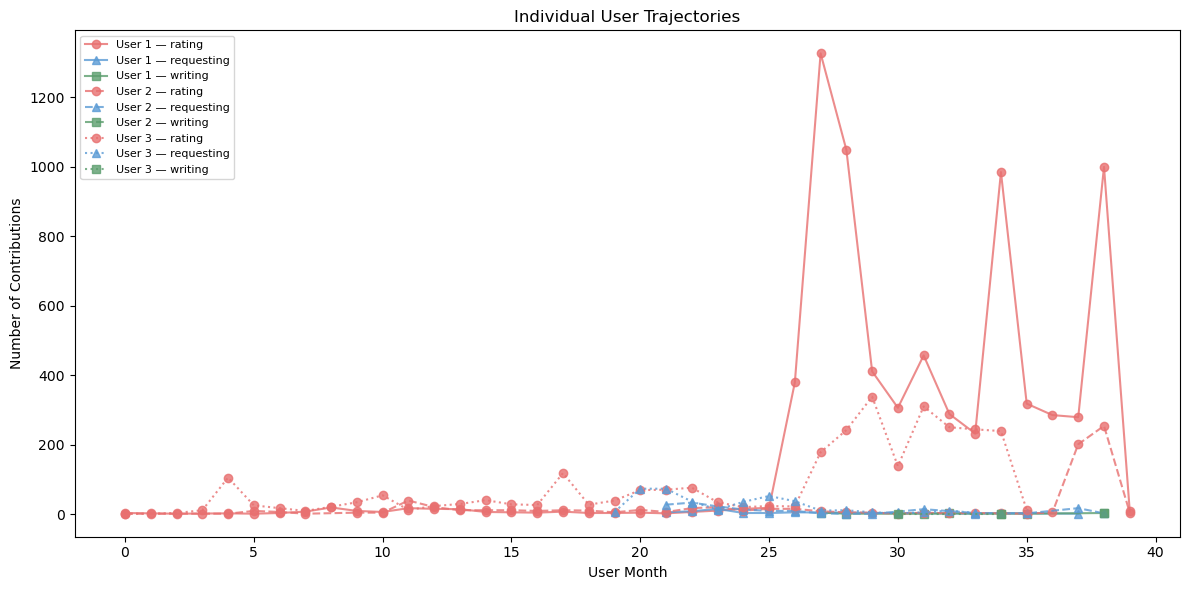

In [4]:
multi_type_users = (
    dominant.groupby('userId')
    .agg(n_months=('userMonth', 'nunique'), n_types=('dominant_type', 'nunique'))
    .reset_index()
    .query('n_months >= 5 and n_types >= 2')
    .sort_values('n_months', ascending=False)
)
sample_users = multi_type_users['userId'].iloc[:3].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
type_markers = {'rating': 'o', 'writing': 's', 'requesting': '^'}
type_colors = {'rating': '#E87070', 'writing': '#5C9E6E', 'requesting': '#5B9BD5'}
user_linestyles = ['-', '--', ':']

for i, uid in enumerate(sample_users):
    user_data = df[df['userId'] == uid].sort_values('userMonth')
    for t, grp in user_data.groupby('type'):
        ax.plot(grp['userMonth'], grp['activity'],
                marker=type_markers.get(t, 'o'),
                linestyle=user_linestyles[i],
                color=type_colors.get(t, 'gray'),
                label=f'User {i+1} — {t}',
                alpha=0.8)

ax.set_xlabel('User Month')
ax.set_ylabel('Number of Contributions')
ax.set_title('Individual User Trajectories')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/q3_individual_trajectories.png', dpi=150)
plt.show()


The individual trajectories show a lot of variation between users. User 1 (blue) is a heavy rater who became dramatically more active around month 25–27, with spikes over 1,300 ratings in a single month. The other users show lower but more consistent activity. Most users have one dominant type that stays stable, but the volume can vary a lot month to month — suggesting that engagement with Community Notes tends to be bursty rather than steady.

## Q4: Average user age by contribution type per calendar month

For each calendar month, I calculated the average `userMonth` of users making each type of contribution. A higher average `userMonth` means the active contributors in that period tend to be more veteran users.

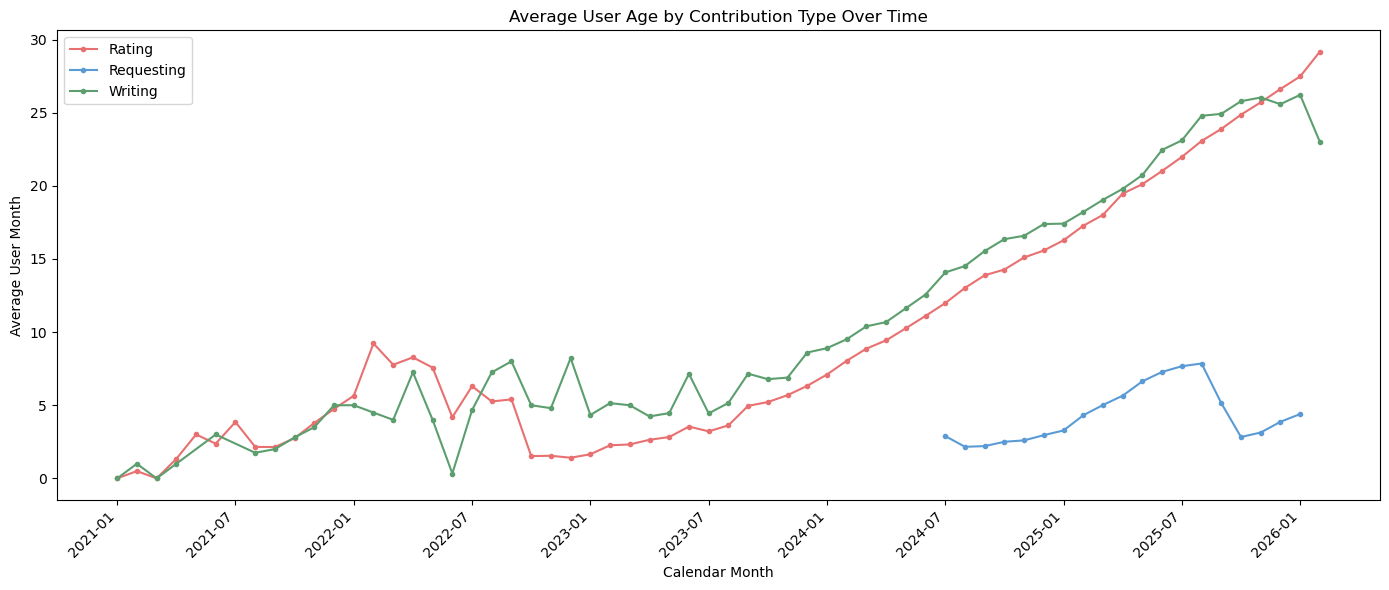

In [5]:
avg_age = (
    df.groupby(['calendarMonth', 'type'])['userMonth']
    .mean()
    .reset_index()
    .rename(columns={'userMonth': 'avg_user_month'})
)

fig, ax = plt.subplots(figsize=(14, 6))
for t, grp in avg_age.groupby('type'):
    grp = grp.sort_values('calendarMonth')
    ax.plot(grp['calendarMonth'], grp['avg_user_month'],
            label=t.capitalize(), marker='o', markersize=3,
            color=colors.get(t, 'gray'))

months = sorted(avg_age['calendarMonth'].unique())
ax.set_xticks(months[::6])
ax.set_xticklabels(months[::6], rotation=45, ha='right')
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Average User Month')
ax.set_title('Average User Age by Contribution Type Over Time')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/q4_avg_user_age_by_type.png', dpi=150)
plt.show()

The average user age has been steadily increasing over time for both rating and writing, which makes sense — as the platform gets older, the active user base accumulates more tenure. By early 2026, the average rater has been on the platform for about 29 months, and note writers for about 25 months.

Requesting users (blue) only appear from mid-2024 onward in this dataset, and their average age stays very low (around 2–8 months). This suggests that requesting is primarily done by newer users, while the longer-tenured users shift toward rating and writing.

## Q5: Contributions by regularity per calendar month

I classified each user's regularity based on how many unique calendar months they were active in (same logic as the weekly regularity from earlier in Issue 59, but applied to months instead of weeks):
- **Irregular**: active in only 1 month
- **Somewhat regular**: active in 2–4 months  
- **Regular**: active in 5+ months

Then I plotted total activity by regularity group per calendar month, for each contribution type.

regularity distribution:
regularity
irregular           12164
somewhat regular     5365
regular              5170
Name: count, dtype: int64


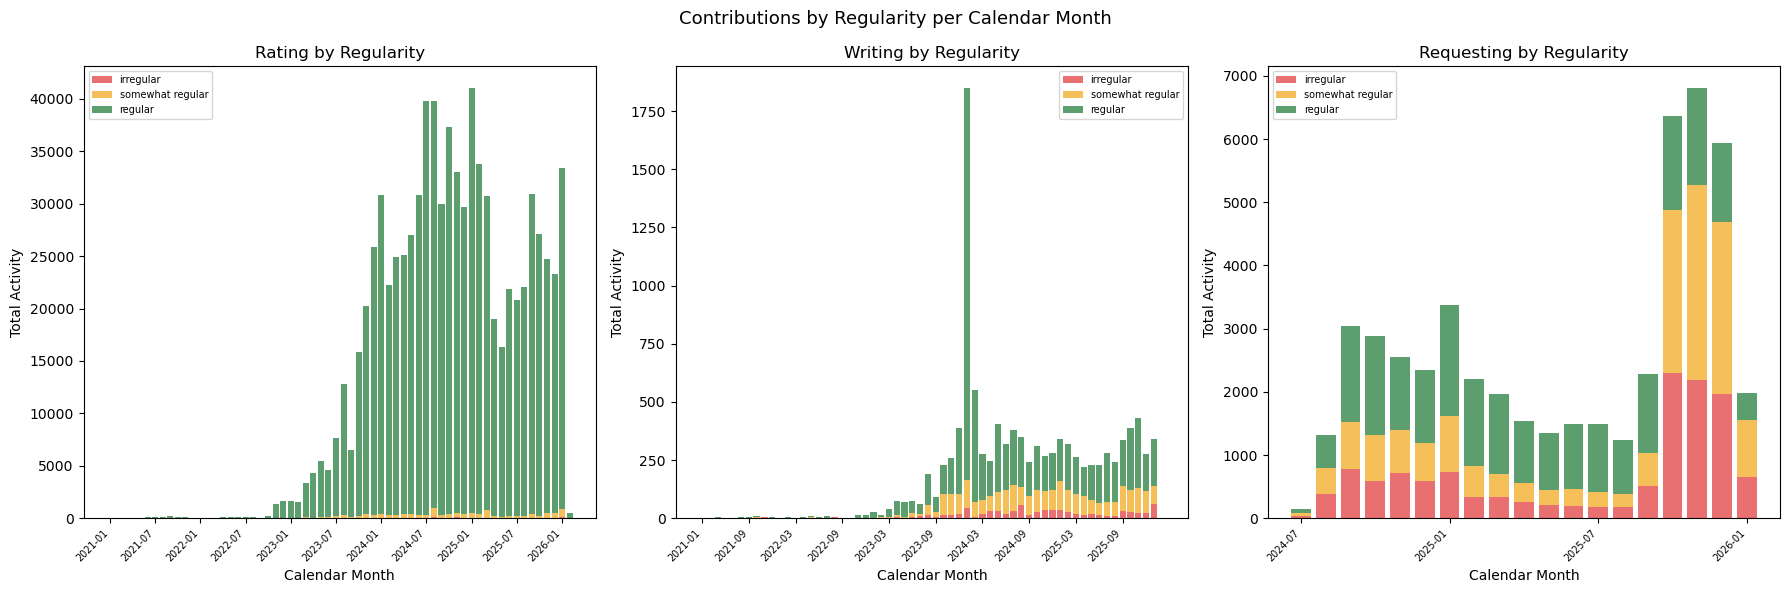

In [6]:
user_active_months = (
    df.groupby(['userId', 'type'])['calendarMonth']
    .nunique()
    .reset_index()
    .rename(columns={'calendarMonth': 'active_months'})
)

def regularity_label(n):
    if n < 2:   return 'irregular'
    elif n < 5: return 'somewhat regular'
    else:       return 'regular'

user_active_months['regularity'] = user_active_months['active_months'].apply(regularity_label)
print('regularity distribution:')
print(user_active_months['regularity'].value_counts())

df2 = df.merge(user_active_months[['userId', 'type', 'regularity']],
               on=['userId', 'type'], how='left')

reg_monthly = (
    df2.groupby(['calendarMonth', 'type', 'regularity'])['activity']
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
types = ['rating', 'writing', 'requesting']
reg_order = ['irregular', 'somewhat regular', 'regular']
reg_colors = {'irregular': '#E87070', 'somewhat regular': '#F5C05A', 'regular': '#5C9E6E'}

for ax, t in zip(axes, types):
    sub = reg_monthly[reg_monthly['type'] == t].sort_values('calendarMonth')
    pivot = sub.pivot(index='calendarMonth', columns='regularity', values='activity').fillna(0)
    pivot = pivot.reindex(columns=reg_order, fill_value=0)
    bottom = np.zeros(len(pivot))
    for reg in reg_order:
        if reg in pivot.columns:
            ax.bar(range(len(pivot)), pivot[reg],
                   bottom=bottom, label=reg,
                   color=reg_colors[reg])
            bottom += pivot[reg].values
    tick_idx = list(range(0, len(pivot), 6))
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([pivot.index[i] for i in tick_idx], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{t.capitalize()} by Regularity')
    ax.set_xlabel('Calendar Month')
    ax.set_ylabel('Total Activity')
    ax.legend(fontsize=7)

plt.suptitle('Contributions by Regularity per Calendar Month', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/q5_contributions_by_regularity.png', dpi=150)
plt.show()

The results are very different across contribution types:

**Rating** is almost entirely driven by regular users (green). Irregular and somewhat regular raters contribute almost nothing in comparison. This makes sense — the volume of ratings is high, and it takes consistent engagement to rack up significant numbers.

**Writing** shows more of a mix. There's one huge spike around early 2024 that is mostly driven by regular writers, but outside of that spike, somewhat regular users make up a larger share. Writing notes is a higher-effort activity, so even users who only write occasionally can still produce meaningful output.

**Requesting** is the most balanced, with irregular and somewhat regular users contributing a substantial share — especially in more recent months. This aligns with what we saw earlier: requesting tends to attract newer, less committed users who may only show up a few times.